In [ ]:
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from timm import create_model
from torch import nn, optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [ ]:
# Define directories
data_dir = "/content/drive/MyDrive/Final-binary"
train_dir = os.path.join(data_dir, "training set")
val_dir = os.path.join(data_dir, "validation set")
test_dir = os.path.join(data_dir, "testing set")

# Count images
def count_images(directory):
    counts = {}
    total = 0
    # Check if the directory exists before listing
    if not os.path.exists(directory):
        print(f"Error: Directory not found - {directory}")
        return counts, total # Return empty counts and zero total
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        # Check if the item in the directory is a directory before listing its contents
        if os.path.isdir(class_path):
            n = len(os.listdir(class_path))
            counts[class_name] = n
            total += n
    return counts, total

train_counts, train_total = count_images(train_dir)
val_counts, val_total = count_images(val_dir)
test_counts, test_total = count_images(test_dir)

print("Train:", train_counts, f"Total: {train_total}")
print("Validation:", val_counts, f"Total: {val_total}")
print("Test:", test_counts, f"Total: {test_total}")

Train: {'psoriasis': 1001, 'non-psoriasis': 891} Total: 1892
Validation: {'psoriasis': 124, 'non-psoriasis': 110} Total: 234
Test: {'psoriasis': 124, 'non-psoriasis': 110} Total: 234


In [ ]:
# Define transforms
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

# Load data
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_dir, transform=test_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

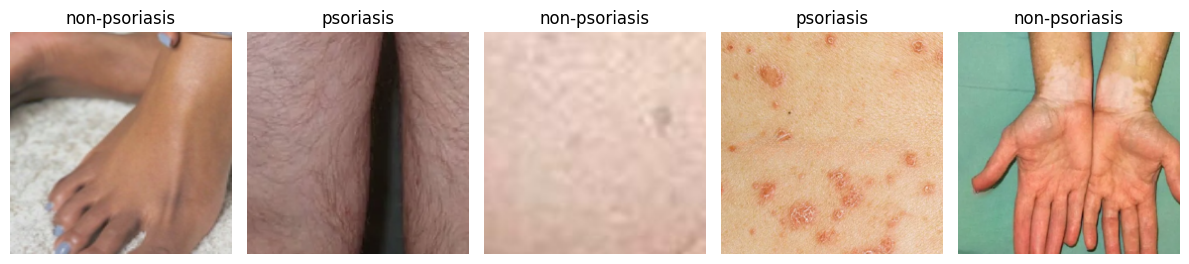

In [ ]:
class_names = train_dataset.classes
def show_augmented_images():
    images, labels = next(iter(train_loader))
    fig, axes = plt.subplots(1, 5, figsize=(12, 5))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(images[i].permute(1, 2, 0))
        ax.set_title(class_names[labels[i]])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_augmented_images()

In [ ]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Teacher model
teacher = create_model('resnet50', pretrained=True, num_classes=1)
teacher = teacher.to(device)   # move teacher to GPU/CPU
teacher.eval()                 # freeze teacher weights

# Student model
student = create_model('deit_base_distilled_patch16_224', pretrained=True, num_classes=1)
student.head = nn.Sequential(
    nn.Dropout(0.6),
    nn.Linear(student.head.in_features, 1)
)
student = student.to(device)   # move student to GPU/CPU

In [ ]:
# Define optimizer
optimizer = optim.Adam(student.parameters(), lr=1e-5)

In [ ]:
# Step 5: Define distillation loss
def distillation_loss(student_logits, teacher_logits, labels, alpha=0.5, T=2.0):
    # Hard target loss (binary classification)
    hard_loss = nn.BCEWithLogitsLoss()(student_logits, labels)
    # Soft target loss (KL divergence with temperature scaling)
    soft_loss = F.kl_div(
        F.log_softmax(student_logits/T, dim=1),
        F.softmax(teacher_logits/T, dim=1),
        reduction='batchmean'
    ) * (T * T)
    return alpha * hard_loss + (1 - alpha) * soft_loss

In [ ]:
criterion = criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)

In [ ]:
# Training loop with accuracy + early stopping
def train_model(student, teacher, train_loader, val_loader, optimizer, epochs=20, patience=5):
    best_val_loss = np.inf
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        student.train()
        train_loss, train_correct, train_total = 0, 0, 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            optimizer.zero_grad()
            with torch.no_grad():
                teacher_outputs = teacher(images).to(device)
            student_outputs = student(images)

            loss = distillation_loss(student_outputs, teacher_outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Accuracy calculation
            probs = torch.sigmoid(student_outputs)
            preds = (probs > 0.5).int()
            train_correct += (preds == labels.int()).sum().item()
            train_total += labels.size(0)

        train_acc = train_correct / train_total
        avg_train_loss = train_loss / len(train_loader)

        # Validation
        student.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.float().unsqueeze(1).to(device)

                teacher_outputs = teacher(images).to(device)
                student_outputs = student(images)

                loss = distillation_loss(student_outputs, teacher_outputs, labels)
                val_loss += loss.item()

                probs = torch.sigmoid(student_outputs)
                preds = (probs > 0.5).int()
                val_correct += (preds == labels.int()).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.4f}, "
              f"Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = student.state_dict()
        else:
            patience_counter += 1
            print(f"⏳ No improvement for {patience_counter}/{patience} epochs.")
        if patience_counter >= patience:
            print("🚨 Early stopping triggered! Restoring best model...")
            student.load_state_dict(best_model_state)
            break

    return student

# Train the student model
trained_student = train_model(student, teacher, train_loader, val_loader, optimizer, epochs=20, patience=5)

Epoch 1: Train Loss=0.5739, Train Acc=0.6919, Val Loss=0.3618, Val Acc=0.8590
Epoch 2: Train Loss=0.3707, Train Acc=0.8356, Val Loss=0.2261, Val Acc=0.9145
Epoch 3: Train Loss=0.2789, Train Acc=0.8895, Val Loss=0.1610, Val Acc=0.9444
Epoch 4: Train Loss=0.2343, Train Acc=0.9101, Val Loss=0.1270, Val Acc=0.9658
Epoch 5: Train Loss=0.2007, Train Acc=0.9149, Val Loss=0.1143, Val Acc=0.9658
Epoch 6: Train Loss=0.1690, Train Acc=0.9403, Val Loss=0.1054, Val Acc=0.9701
Epoch 7: Train Loss=0.1365, Train Acc=0.9429, Val Loss=0.0797, Val Acc=0.9786
Epoch 8: Train Loss=0.1184, Train Acc=0.9551, Val Loss=0.0838, Val Acc=0.9744
⏳ No improvement for 1/5 epochs.
Epoch 9: Train Loss=0.1074, Train Acc=0.9646, Val Loss=0.0653, Val Acc=0.9872
Epoch 10: Train Loss=0.0908, Train Acc=0.9693, Val Loss=0.0603, Val Acc=0.9786
Epoch 11: Train Loss=0.0735, Train Acc=0.9757, Val Loss=0.1108, Val Acc=0.9487
⏳ No improvement for 1/5 epochs.
Epoch 12: Train Loss=0.1020, Train Acc=0.9656, Val Loss=0.0616, Val Acc=0.

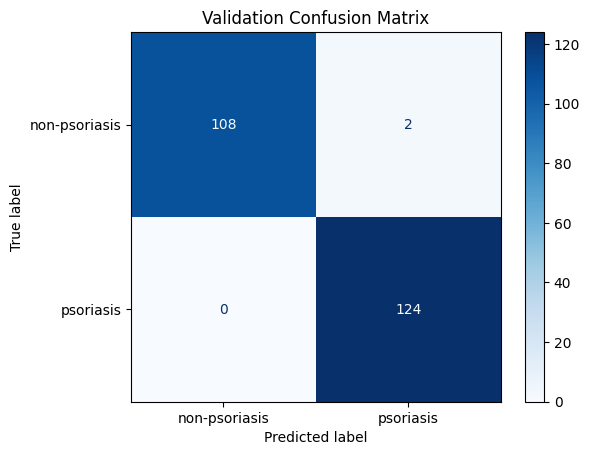

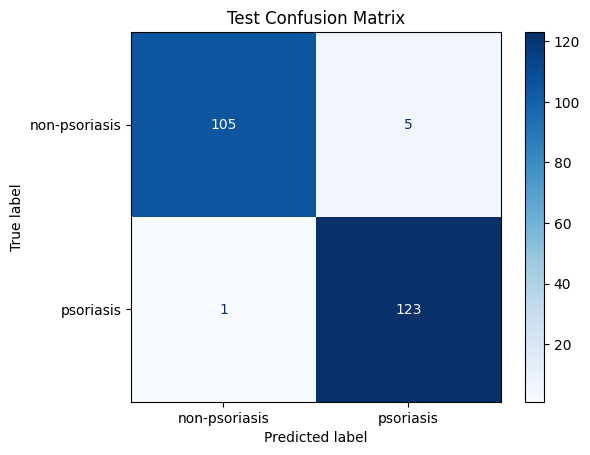

In [ ]:
def evaluate(model_to_evaluate, loader, title):
    y_true, y_pred = [], []
    model_to_evaluate.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device) # Make sure shape is [batch_size, 1]
            outputs = model_to_evaluate(images)
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{title} Confusion Matrix")
    plt.show()

evaluate(student, val_loader, "Validation")
evaluate(student, test_loader, "Test")

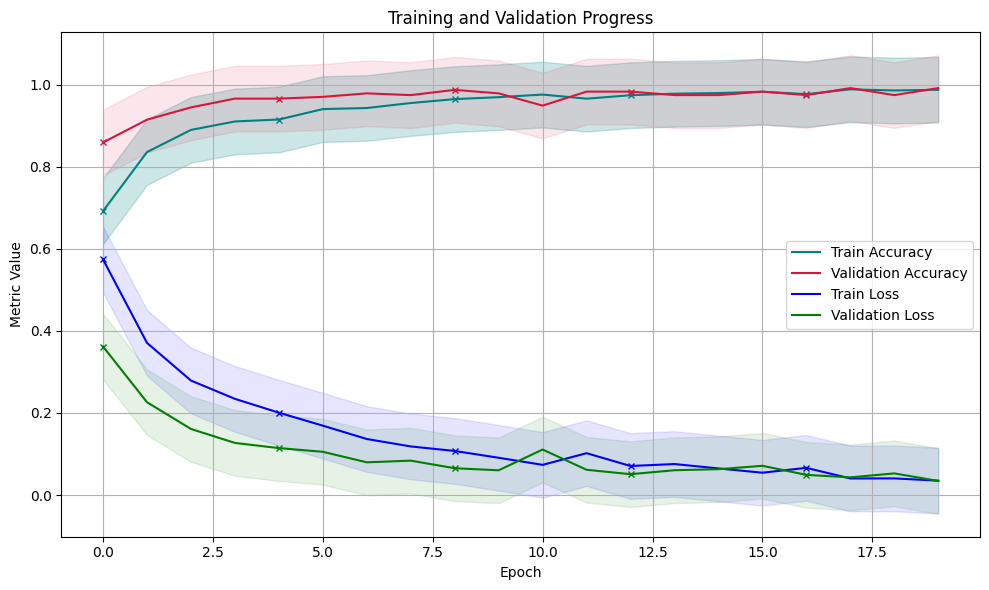

In [ ]:
# Check if training variables exist before plotting
if 'train_losses' in locals() and 'val_losses' in locals() and 'train_accuracies' in locals() and 'val_accuracies' in locals():
    # Plot accuracy and loss on a single graph with enhancements
    plt.figure(figsize=(10, 6))

    epochs = range(len(train_accuracies)) # Use the length of the accuracy list for epochs
    offset = 0.08 # Define a small offset for the shaded area - Increased for wider shadow
    marker_interval = max(1, len(epochs) // 5) # Calculate interval to get at most 10 markers

    # Plot training and validation accuracy
    plt.plot(epochs, train_accuracies, label='Train Accuracy', color='teal', linestyle='-')
    plt.plot(epochs[::marker_interval], np.array(train_accuracies)[::marker_interval], 'x', color='teal', markersize= 4) # Add wider markers
    plt.fill_between(epochs, np.array(train_accuracies) - offset, np.array(train_accuracies) + offset, color='teal', alpha=0.2) # Add shaded area around the line
    plt.plot(epochs, val_accuracies, label='Validation Accuracy', color='crimson')
    plt.plot(epochs[::marker_interval], np.array(val_accuracies)[::marker_interval], 'x', color='crimson', markersize= 4) # Add wider markers
    plt.fill_between(epochs, np.array(val_accuracies) - offset, np.array(val_accuracies) + offset, color='crimson', alpha=0.1) # Add shaded area around the line

    plt.plot(epochs, train_losses, label='Train Loss', color='blue')
    plt.plot(epochs[::marker_interval], np.array(train_losses)[::marker_interval], 'x', color='blue', markersize=4) # Add wider markers
    plt.fill_between(epochs, np.array(train_losses) - offset, np.array(train_losses) + offset, color='blue', alpha=0.1) # Add shaded area around the line
    plt.plot(epochs, val_losses, label='Validation Loss', color='green') # Using a different color for clarity
    plt.plot(epochs[::marker_interval], np.array(val_losses)[::marker_interval], 'x', color='green', markersize=4) # Add wider markers
    plt.fill_between(epochs, np.array(val_losses) - offset, np.array(val_losses) + offset, color='green', alpha=0.1) # Add shaded area around the line


    plt.title("Training and Validation Progress")
    plt.xlabel("Epoch")
    plt.ylabel("Metric Value") # Generic label as it includes both accuracy and loss
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-2195024235.py:43: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


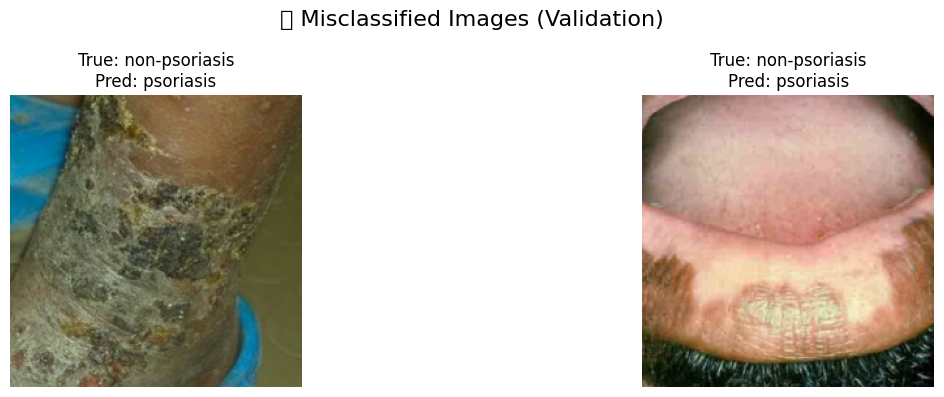

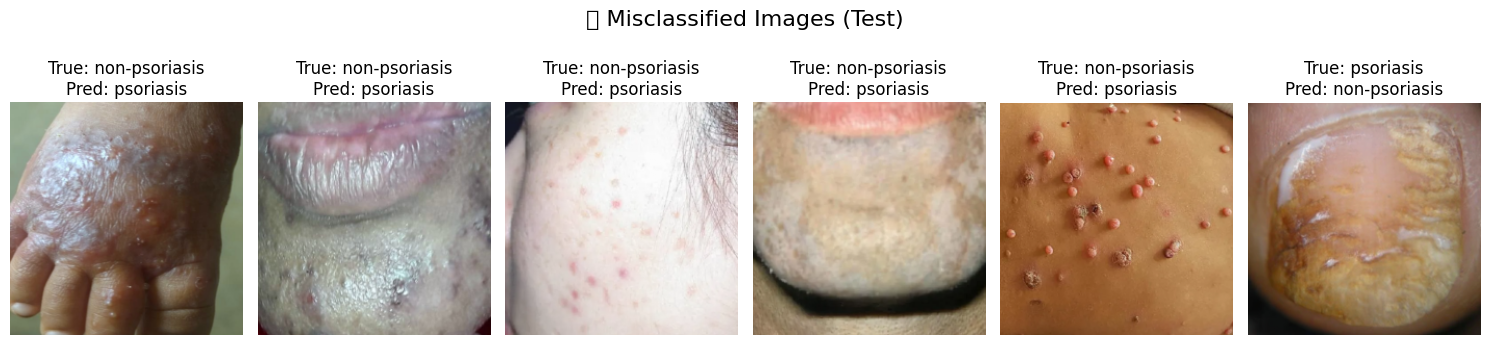

In [ ]:
import matplotlib.pyplot as plt

def show_misclassified_images(model_to_evaluate, loader, dataset_name="Dataset", max_images=10):
    model_to_evaluate.eval()
    misclassified = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model_to_evaluate(images)
            # Use sigmoid and a threshold for binary classification
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()

            # Flatten labels and predictions for easier comparison
            labels = labels.view(-1)
            preds = preds.view(-1)


            for img, true_label, pred_label in zip(images, labels, preds):
                if true_label != pred_label:
                    misclassified.append((img.cpu(), true_label.cpu(), pred_label.cpu()))

    if not misclassified:
        print(f"No misclassified images found in {dataset_name} 🎉")
        return

    # Show the first few misclassified
    num_images = min(len(misclassified), max_images)
    fig, axes = plt.subplots(1, num_images, figsize=(15, 4))
    # Handle the case where there is only one misclassified image
    if num_images == 1:
        axes = [axes]

    for i in range(num_images):
        image, true_label, pred_label = misclassified[i]
        # Permute dimensions for displaying images (C, H, W) -> (H, W, C)
        axes[i].imshow(image.permute(1, 2, 0))
        axes[i].set_title(f"True: {class_names[true_label.item()]}\nPred: {class_names[pred_label.item()]}")
        axes[i].axis("off")
    plt.suptitle(f"❌ Misclassified Images ({dataset_name})", fontsize=16)
    plt.tight_layout()
    plt.show()

# Example usage:
show_misclassified_images(student, val_loader, "Validation")
show_misclassified_images(student, test_loader, "Test")

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score
)

def compute_metrics(model_to_evaluate, loader, name):
    model_to_evaluate.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model_to_evaluate(images)
            # For binary classification with BCEWithLogitsLoss, use sigmoid and a threshold
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).int()


            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    # Confusion matrix components
    cm = confusion_matrix(all_labels, all_preds)
    # Handle cases where a class might not be predicted
    if cm.shape == (1, 1):
        TN = cm[0, 0] if all_labels[0] == 0 else 0
        TP = cm[0, 0] if all_labels[0] == 1 else 0
        FP = 0
        FN = 0
    elif cm.shape == (2, 2):
        TN, FP, FN, TP = cm.ravel()
    else:
        # Handle other shapes if necessary, or raise an error
        raise ValueError(f"Unexpected confusion matrix shape: {cm.shape}")


    # Metrics
    accuracy = accuracy_score(all_labels, all_preds)
    # Handle potential division by zero in precision, recall, f1-score
    precision = precision_score(all_labels, all_preds, zero_division=1)
    recall = recall_score(all_labels, all_preds, zero_division=1)
    f1 = f1_score(all_labels, all_preds, zero_division=1)
    sensitivity = recall  # Same as recall

    # Handle the case where TN + FP is zero for specificity
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 1.0


    print(f"\n📊 {name} Metrics")
    print("---------------------------")
    print(f"Accuracy   : {accuracy:.4f}")
    print(f"Precision  : {precision:.4f}")
    print(f"Recall     : {recall:.4f}")
    print(f"F1 Score   : {f1:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print(f"Specificity: {specificity:.4f}")

# Example:
compute_metrics(student, val_loader, "Validation")
compute_metrics(student, test_loader, "Test")


📊 Validation Metrics
---------------------------
Accuracy   : 0.9915
Precision  : 0.9841
Recall     : 1.0000
F1 Score   : 0.9920
Sensitivity: 1.0000
Specificity: 0.9818

📊 Test Metrics
---------------------------
Accuracy   : 0.9744
Precision  : 0.9609
Recall     : 0.9919
F1 Score   : 0.9762
Sensitivity: 0.9919
Specificity: 0.9545


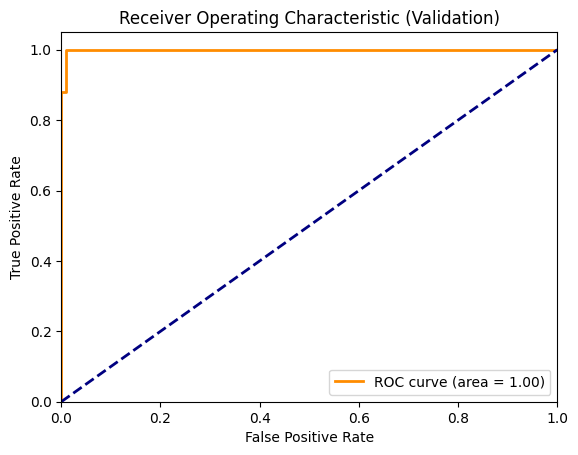

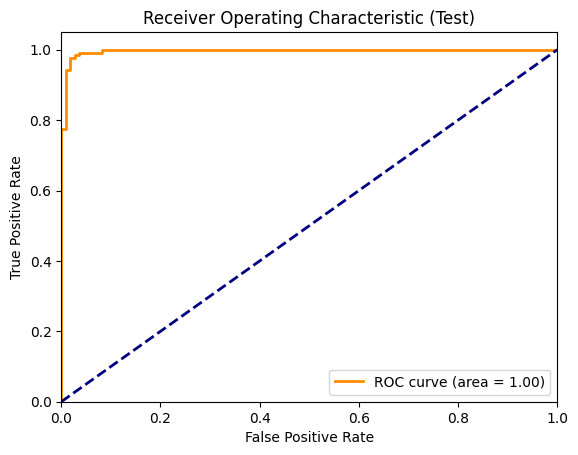

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model_to_evaluate, loader, name):
    model_to_evaluate.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model_to_evaluate(images)
            probs = torch.sigmoid(outputs) # Get probabilities for ROC curve

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic ({name})')
    plt.legend(loc="lower right")
    plt.show()

plot_roc_curve(student, val_loader, "Validation")
plot_roc_curve(student, test_loader, "Test")

In [ ]:
torch.save(student.state_dict(), "student_model.pth")